<a href="https://colab.research.google.com/github/Mattmflores/ADTA_Group_8/blob/main/pivot_point_driven.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Helper Functions

In [16]:
# Function: get_pivot_xy
# Parameters:
#     t         - array_like : time values (s)
#     omega_d   - float      : driving angular frequency (rad/s)
#     x_p0, y_p0 - float     : optional offsets for pivot’s origin (default = 0)
#     l         - float      : pendulum length or radius of circular path (default = 1)
# Returns:
#     x_p, y_p  - ndarrays : pivot coordinates over time
# Description:
#     Computes the motion of the pendulum pivot point following
#     the assignment definition:
#         x_p(t) = -l * sin(ω_d * t)
#         y_p(t) =  l * (1 - cos(ω_d * t))
#     This describes a circular path of radius l about the origin.
def get_pivot_xy(t, omega_d, x_p0=0.0, y_p0=0.0, l=1.0):
    x_p = -l * np.sin(omega_d * t) + x_p0
    y_p =  l * (1 - np.cos(omega_d * t)) + y_p0
    return x_p, y_p


In [17]:
# Function: get_pendulum_xy
# Parameters:
#     t       - array_like : time array (not directly used)
#     theta   - array_like : angular displacement (rad)
#     l       - float      : pendulum length (default = 1)
# Returns:
#     x_rel, y_rel - ndarrays : pendulum bob coordinates relative to the pivot
# Description:
#     Computes the bob’s position relative to the pivot using
#     the small-angle pendulum geometry:
#         x_rel =  l * sin(θ)
#         y_rel = -l * cos(θ)
#     The reference θ = 0 corresponds to the bob hanging straight down.
def get_pendulum_xy(t, theta, l=1.0):
    x_rel = l * np.sin(theta)
    y_rel = -l * np.cos(theta)
    return x_rel, y_rel

In [18]:
# Function: get_lab_xy
# Parameters:
#     x_pivot, y_pivot - array_like : pivot coordinates
#     x_rel, y_rel     - array_like : bob coordinates relative to pivot
# Returns:
#     x_lab, y_lab     - ndarrays : bob coordinates in the lab frame
# Description:
#     Converts pendulum coordinates from the pivot frame to the
#     laboratory frame by adding the pivot’s motion to the bob’s
#     relative displacement.
def get_lab_xy(x_pivot, y_pivot, x_rel, y_rel):
    x_lab = x_pivot + x_rel
    y_lab = y_pivot + y_rel
    return x_lab, y_lab

## Pendulum Equation of Motion

In [19]:
# Function: pendulum_rhs
# Parameters:
#     t       - float      : current time (s)
#     y       - list/array : [theta, theta_dot]
#     l       - float      : pendulum length (m)
#     g       - float      : acceleration due to gravity (m/s^2)
#     omega_d - float      : drive angular frequency (rad/s)
# Returns:
#     dydt    - list : time derivatives [theta_dot, theta_ddot]
# Description:
#     Computes the derivatives of the pivot-driven pendulum system.
#     The governing equation of motion is derived from Newton’s
#     second law or Lagrange’s equations:
#
#         θ¨ + (g/l) * sin(θ) = -ω_d² * sin(ω_d * t + θ)
#
#     This represents a rigid pendulum whose pivot moves in a
#     circular path with drive frequency ω_d. The acceleration of
#     the pivot introduces an additional forcing term that depends
#     on both time and the instantaneous angle θ.
def pendulum_rhs(t, y, l, g, omega_d):
    theta, theta_dot = y  # unpack the state vector

    # second derivative (angular acceleration)
    theta_ddot = - (g / l) * np.sin(theta) - (omega_d ** 2) * np.sin(omega_d * t + theta)

    # return time derivatives as list
    return [theta_dot, theta_ddot]


## Numerical Integration of the Pendulum Equation

In [20]:
# Physical and simulation parameters
g = 9.81            # gravitational acceleration (m/s^2)
l = 1.0             # pendulum length (m)
omega_d = 3.0       # drive angular frequency (rad/s)
t_min, t_max = 0.0, 10.0  # simulation time range (s)
x_p0 = 0.0
y_p0 = 0.0

# Initial conditions
y0 = [0.0, 0.0]

In [21]:
# Numerical integration using RK45 method
sol = solve_ivp(
    fun=lambda t, y: pendulum_rhs(t, y, l, g, omega_d),
    t_span=(t_min, t_max),
    y0=y0,
    method='RK45',
    dense_output=True,   # allows continuous interpolation θ(t)
    max_step=0.01        # small step for smoother animation
)

In [22]:
# Evaluate solution
t_plot = np.linspace(t_min, t_max, 1000)
theta_plot = sol.sol(t_plot)[0]  # θ(t)

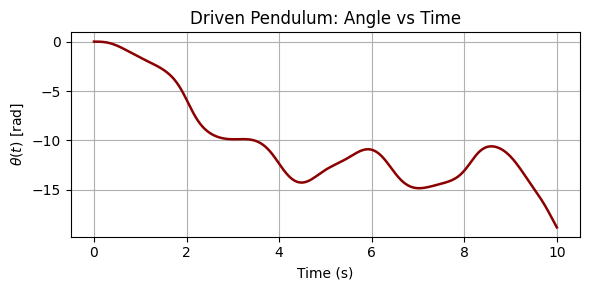

In [23]:
# Plot
plt.figure(figsize=(6, 3))
plt.plot(t_plot, theta_plot, color='darkred', lw=1.8)
plt.title("Driven Pendulum: Angle vs Time")
plt.xlabel("Time (s)")
plt.ylabel(r"$\theta(t)$ [rad]")
plt.grid(True)
plt.tight_layout()
plt.show()


## Animation

In [24]:
# Function: create_pendulum_animation
# Parameters:
#     t           - ndarray : time array used for the animation frames
#     x_pivot     - ndarray : pivot x-coordinates over time
#     y_pivot     - ndarray : pivot y-coordinates over time
#     x_lab       - ndarray : bob x-coordinates in lab frame over time
#     y_lab       - ndarray : bob y-coordinates in lab frame over time
#     l           - float   : pendulum length (default = 1)
#     show_traj   - bool    : if True, plot the bob's full trajectory
#     speed_factor- float   : >1 slows animation, <1 speeds it up
# Returns:
#     anim        - FuncAnimation : matplotlib animation object
# Description:
#     Builds a 2D animation of the pivot-driven pendulum. The pivot
#     is drawn as a black dot, the rod as a black line, and the bob
#     as a red dot. Optionally, the trajectory of the bob can be
#     plotted to visualize the path in the lab frame.

def create_pendulum_animation(t, x_pivot, y_pivot, x_lab, y_lab,
                              l=1, show_traj=False, speed_factor=1.0):

    # create figure and axis
    fig, ax = plt.subplots(figsize=(4, 4))

    # set axis limits so everything fits
    ax.set_xlim(np.min(x_pivot) - l, np.max(x_pivot) + l)
    ax.set_ylim(np.min(y_pivot) - l, np.max(y_pivot) + l)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # static plot elements
    pivot, = ax.plot([], [], 'o', color='black', markersize=8, label='Pivot')
    pendulum_arm, = ax.plot([], [], '-', color='black', lw=2, label='Pendulum Arm')
    pendulum_bob, = ax.plot([], [], 'o', color='red', markersize=12, label='Pendulum Bob')

    # optional trajectory line
    trajectory = None
    if show_traj:
        trajectory, = ax.plot([], [], '-', color='gray', lw=1, alpha=0.5, label='Trajectory')


    def animate(i):
        # update pivot position
        pivot.set_data([x_pivot[i]], [y_pivot[i]])

        # update rod from pivot to bob
        pendulum_arm.set_data([x_pivot[i], x_lab[i]], [y_pivot[i], y_lab[i]])

        # update bob position
        pendulum_bob.set_data([x_lab[i]], [y_lab[i]])

        artists = [pivot, pendulum_arm, pendulum_bob]

        # if trajectory is enabled, update it
        if show_traj and trajectory:
            trajectory.set_data(x_lab[:i+1], y_lab[:i+1])
            artists.append(trajectory)

        return artists

    # choose interval from average time step, scaled
    avg_dt = np.mean(np.diff(t))
    interval = avg_dt * 1000 * speed_factor  # ms

    # build animation
    anim = FuncAnimation(fig, animate, frames=len(t), interval=interval, blit=True)

    # prevent duplicate static figure
    plt.close(fig)

    return anim


In [25]:
# number of frames in the animation
n_points = 300
t_plot = np.linspace(t_min, t_max, n_points)

# angle from the solver (requires dense_output=True, which we set)
theta_plot = sol.sol(t_plot)[0]

# pivot coordinates (exact assignment signature)
x_pivot, y_pivot = get_pivot_xy(t_plot, omega_d, x_p0, y_p0)

# pendulum coordinates relative to pivot (use their names)
x_pendulum, y_pendulum = get_pendulum_xy(t_plot, theta_plot, l)

# lab-frame coordinates
x_lab, y_lab = get_lab_xy(x_pivot, y_pivot, x_pendulum, y_pendulum)

# animation flags/parameters
show_traj = True
speed_factor = 5

# create animation (exact signature from assignment)
pendulum_animation = create_pendulum_animation(
    t_plot, x_pivot, y_pivot, x_lab, y_lab,
    l=l, show_traj=show_traj, speed_factor=speed_factor
)

HTML(pendulum_animation.to_html5_video())

